# 1. Exploratory Data Analysis — Dog Breed Identification

**Objective:** Understand the dataset before building any model. We analyze the distribution of breeds, image properties (size, aspect ratio), and visualize samples from different classes.

**Dataset:** [Kaggle Dog Breed Identification](https://www.kaggle.com/competitions/dog-breed-identification/data)  
- 10,222 labeled training images  
- 10,357 unlabeled test images  
- 120 dog breeds  

**Key questions:**
1. Is the dataset balanced across breeds?
2. What are the image dimensions and aspect ratios?
3. What do representative samples look like per breed?
4. Are there any data quality issues (corrupt images, duplicates)?

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter

sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

## 1.1 Loading and Inspecting Labels

In [2]:
labels_df = pd.read_csv(DATA_DIR / "labels.csv")
print(f"Total training samples: {len(labels_df)}")
print(f"Number of breeds: {labels_df['breed'].nunique()}")
print(f"\nFirst 10 rows:")
labels_df.head(10)

Total training samples: 10222
Number of breeds: 120

First 10 rows:


,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever
5,002211c81b498ef88e1b40b9abf84e1d,bedlington_terrier
6,00290d3e1fdd27226ba27a8ce248ce85,bedlington_terrier
7,002a283a315af96eaea0e28e7163b21b,borzoi
8,003df8b8a8b05244b1d920bb6cf451f9,basenji
9,0042188c895a2f14ef64a918ed9c7b64,scottish_deerhound


In [3]:
# Verify all training images exist on disk
labels_df["file_exists"] = labels_df["id"].apply(
    lambda x: (TRAIN_DIR / f"{x}.jpg").exists()
)
missing = labels_df[~labels_df["file_exists"]]
print(f"Missing images: {len(missing)}")
if len(missing) > 0:
    print(missing.head())

Missing images: 0


## 1.2 Breed Distribution

Understanding class imbalance is critical — it directly affects model training. If some breeds have significantly fewer samples, we may need strategies like oversampling, class weights, or data augmentation.

In [4]:
breed_counts = labels_df["breed"].value_counts()

print(f"Samples per breed — min: {breed_counts.min()}, max: {breed_counts.max()}, "
      f"mean: {breed_counts.mean():.1f}, std: {breed_counts.std():.1f}")
print(f"\nTop 10 breeds:\n{breed_counts.head(10)}")
print(f"\nBottom 10 breeds:\n{breed_counts.tail(10)}")

Samples per breed — min: 66, max: 126, mean: 85.2, std: 13.3

Top 10 breeds:
breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
shih-tzu                112
great_pyrenees          111
pomeranian              111
basenji                 110
samoyed                 109
Name: count, dtype: int64

Bottom 10 breeds:
breed
walker_hound         69
otterhound           69
giant_schnauzer      69
german_shepherd      69
tibetan_mastiff      69
golden_retriever     67
komondor             67
brabancon_griffon    67
eskimo_dog           66
briard               66
Name: count, dtype: int64


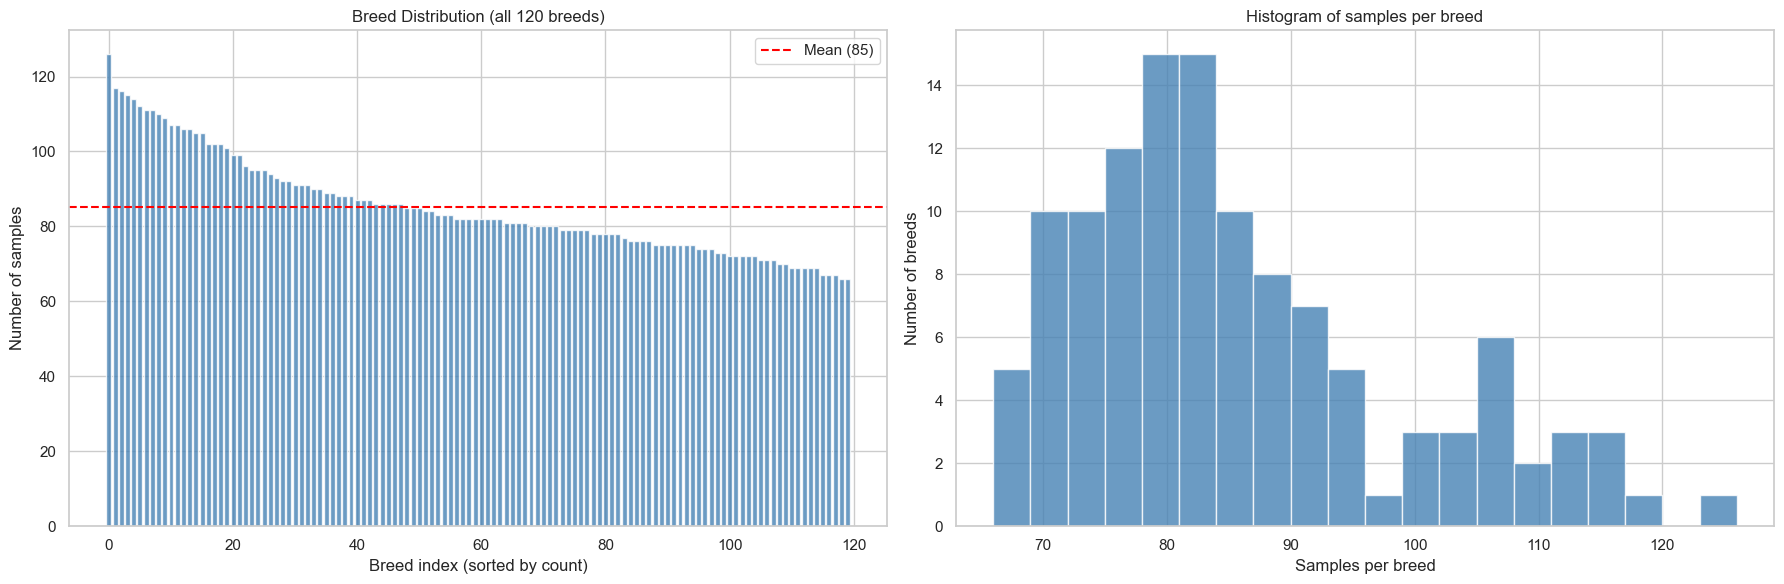


Imbalance ratio (max/min): 1.9x


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full distribution
axes[0].bar(range(len(breed_counts)), breed_counts.values, color="steelblue", alpha=0.8)
axes[0].axhline(y=breed_counts.mean(), color="red", linestyle="--", label=f"Mean ({breed_counts.mean():.0f})")
axes[0].set_xlabel("Breed index (sorted by count)")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Breed Distribution (all 120 breeds)")
axes[0].legend()

# Histogram
axes[1].hist(breed_counts.values, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Samples per breed")
axes[1].set_ylabel("Number of breeds")
axes[1].set_title("Histogram of samples per breed")

plt.tight_layout()
plt.savefig("../notebooks/figures/breed_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Imbalance ratio
imbalance_ratio = breed_counts.max() / breed_counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.1f}x")

## 1.3 Image Properties

We need to understand image dimensions to decide on the input size for our models. Variable-sized images require resizing — knowing the distribution helps us choose a good target size.

In [6]:
# Sample a subset for efficiency (analyzing all 10k images takes time)
sample_ids = labels_df["id"].sample(n=1000, random_state=42).tolist()

widths, heights, aspect_ratios, file_sizes = [], [], [], []
corrupt_images = []

for img_id in sample_ids:
    img_path = TRAIN_DIR / f"{img_id}.jpg"
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
            file_sizes.append(os.path.getsize(img_path) / 1024)  # KB
    except Exception as e:
        corrupt_images.append((img_id, str(e)))

print(f"Analyzed {len(widths)} images ({len(corrupt_images)} corrupt)")
print(f"\nWidth  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Aspect ratio — min: {min(aspect_ratios):.2f}, max: {max(aspect_ratios):.2f}, mean: {np.mean(aspect_ratios):.2f}")
print(f"File size (KB) — min: {min(file_sizes):.0f}, max: {max(file_sizes):.0f}, mean: {np.mean(file_sizes):.0f}")

if corrupt_images:
    print(f"\nCorrupt images: {corrupt_images}")

Analyzed 1000 images (0 corrupt)

Width  — min: 112, max: 2048, mean: 442
Height — min: 120, max: 1879, mean: 391
Aspect ratio — min: 0.42, max: 2.16, mean: 1.17
File size (KB) — min: 4, max: 653, mean: 35


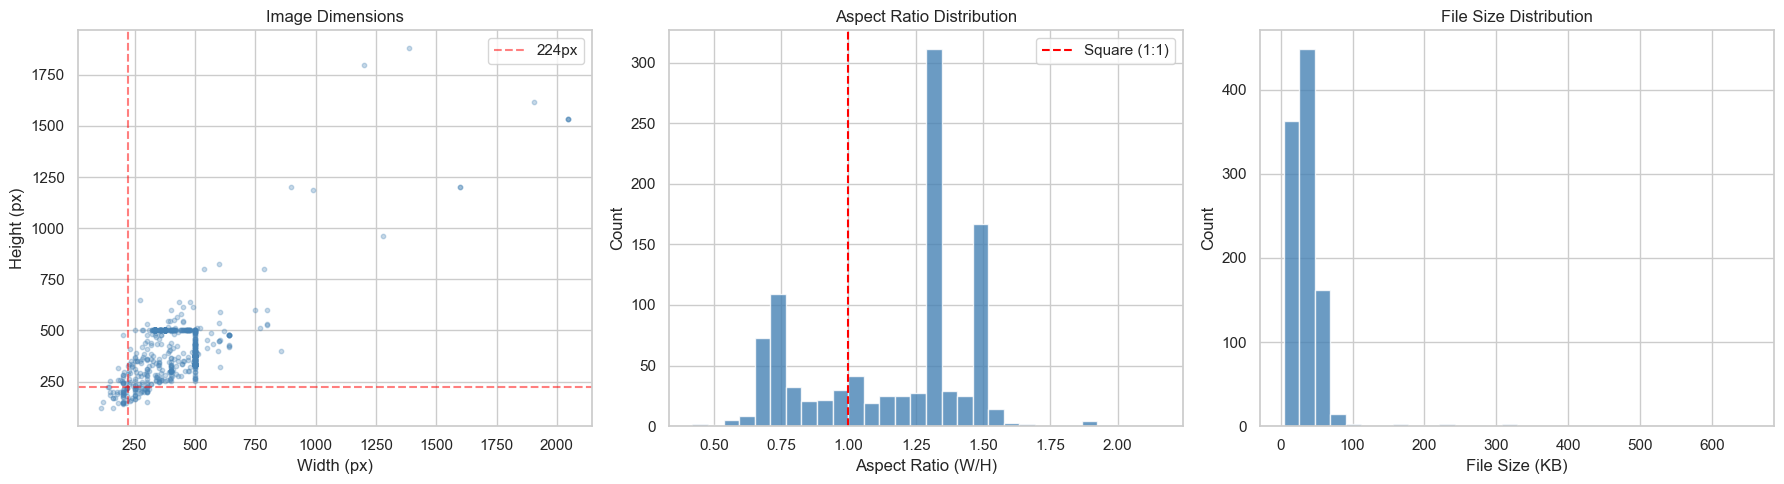

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width vs Height scatter
axes[0].scatter(widths, heights, alpha=0.3, s=10, color="steelblue")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Image Dimensions")
axes[0].axhline(y=224, color="red", linestyle="--", alpha=0.5, label="224px")
axes[0].axvline(x=224, color="red", linestyle="--", alpha=0.5)
axes[0].legend()

# Aspect ratio histogram
axes[1].hist(aspect_ratios, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(x=1.0, color="red", linestyle="--", label="Square (1:1)")
axes[1].set_xlabel("Aspect Ratio (W/H)")
axes[1].set_ylabel("Count")
axes[1].set_title("Aspect Ratio Distribution")
axes[1].legend()

# File size histogram
axes[2].hist(file_sizes, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
axes[2].set_xlabel("File Size (KB)")
axes[2].set_ylabel("Count")
axes[2].set_title("File Size Distribution")

plt.tight_layout()
plt.savefig("../notebooks/figures/image_properties.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.4 Sample Visualization

Visualizing representative images per breed helps us understand the visual complexity of the task. Some breeds are visually very similar (e.g., different terrier types), which we expect to be a challenge for the model.

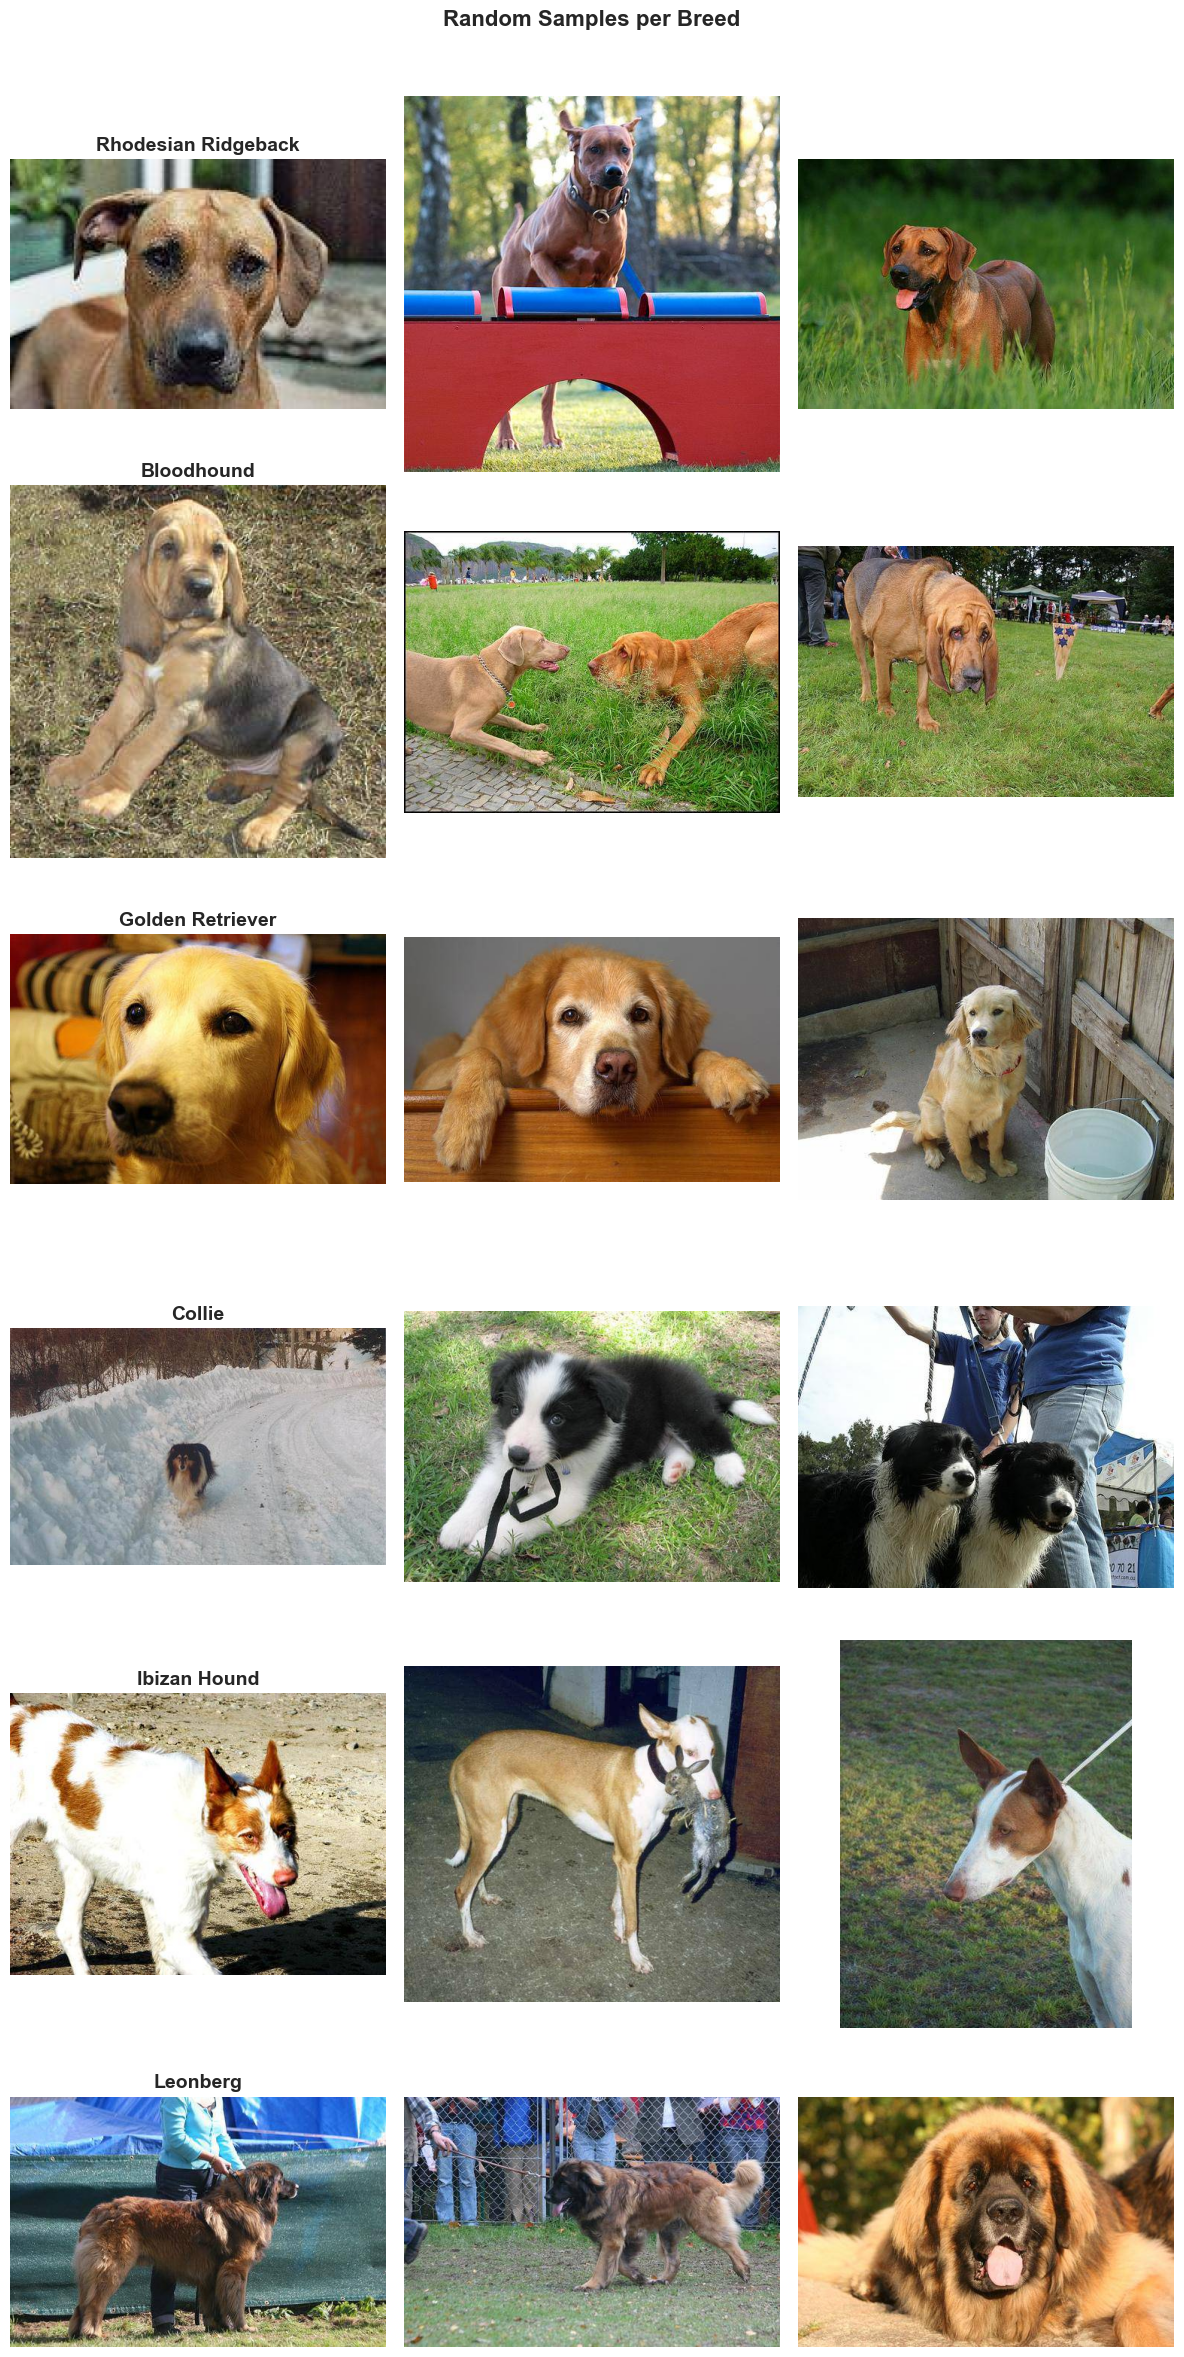

In [8]:
# Show 3 random samples from 6 random breeds
np.random.seed(42)
sample_breeds = np.random.choice(labels_df["breed"].unique(), size=6, replace=False)

fig, axes = plt.subplots(6, 3, figsize=(12, 24))

for i, breed in enumerate(sample_breeds):
    breed_ids = labels_df[labels_df["breed"] == breed]["id"].tolist()
    sample = np.random.choice(breed_ids, size=min(3, len(breed_ids)), replace=False)
    for j, img_id in enumerate(sample):
        img = Image.open(TRAIN_DIR / f"{img_id}.jpg")
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(breed.replace("_", " ").title(), fontsize=14, fontweight="bold")

plt.suptitle("Random Samples per Breed", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../notebooks/figures/sample_breeds.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.5 Visually Similar Breeds

Identifying breeds that look alike will help us later interpret confusion matrices and understand model errors.

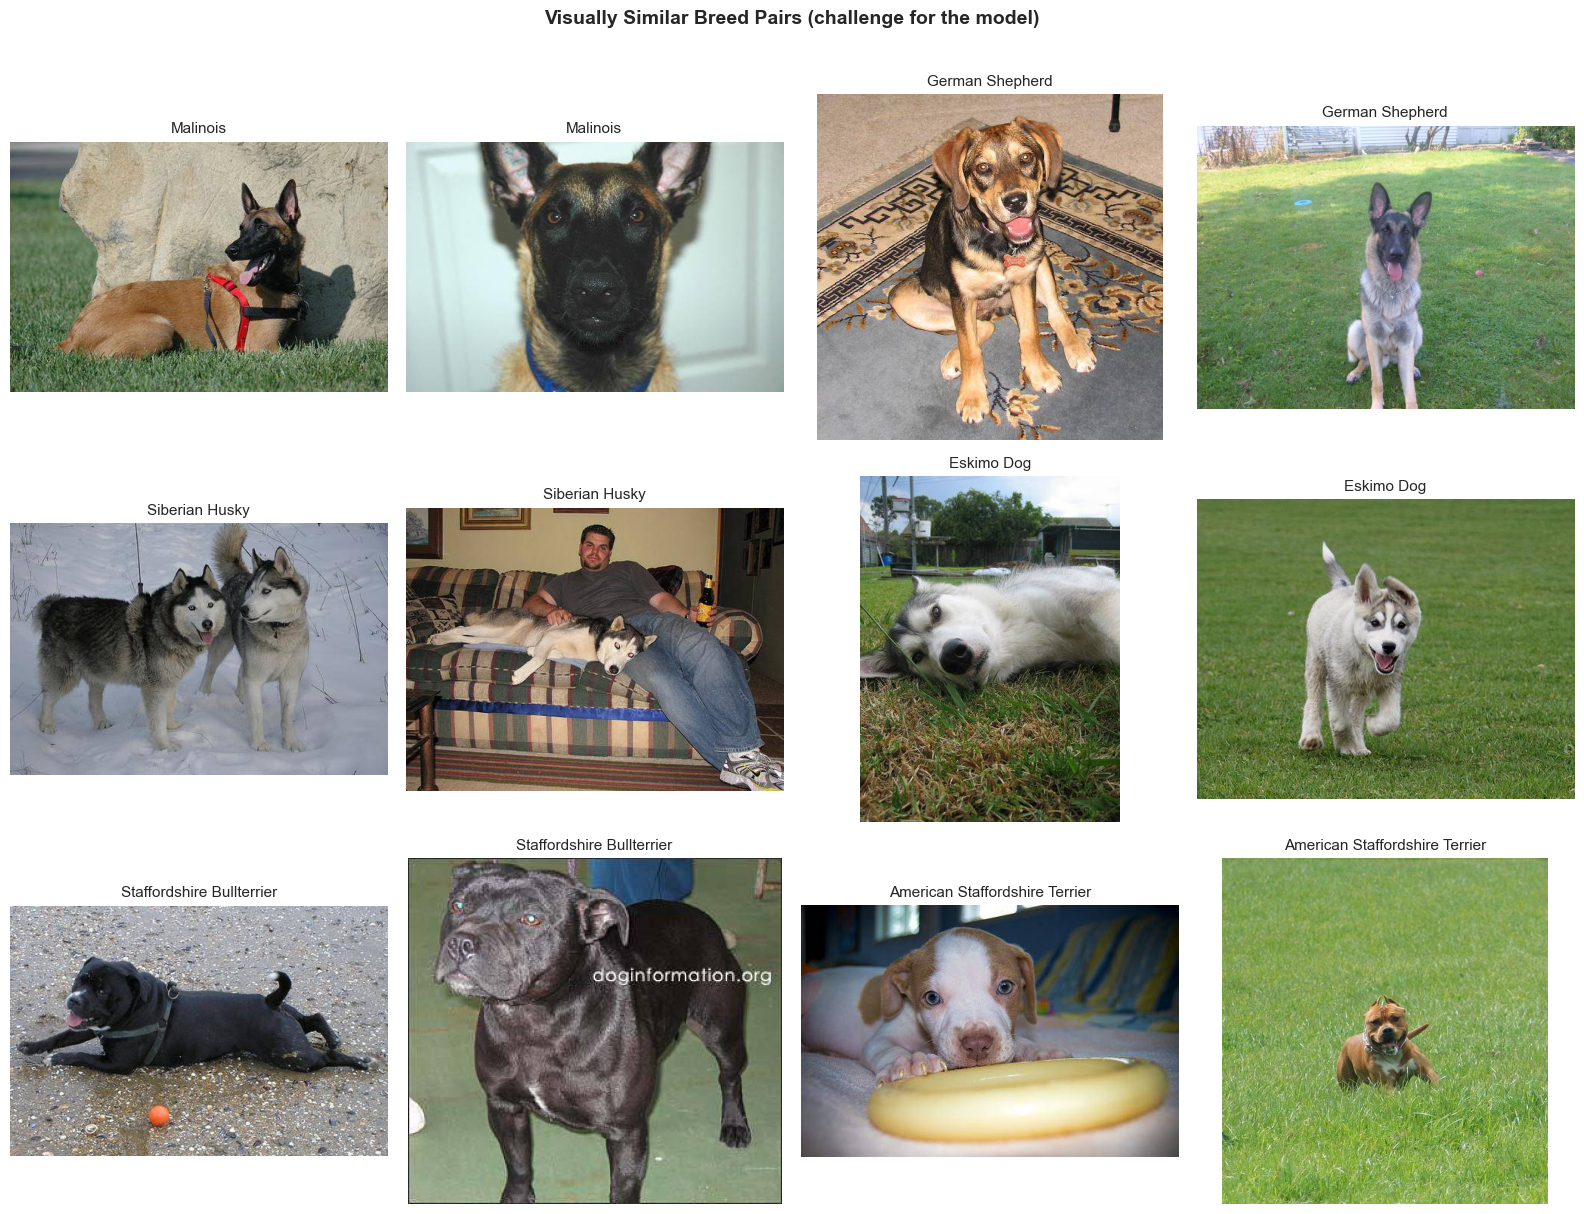

In [9]:
# Show pairs of breeds that are known to be visually similar
similar_pairs = [
    ("malinois", "german_shepherd"),
    ("siberian_husky", "eskimo_dog"),
    ("staffordshire_bullterrier", "american_staffordshire_terrier"),
]

fig, axes = plt.subplots(len(similar_pairs), 4, figsize=(16, 4 * len(similar_pairs)))

for i, (breed_a, breed_b) in enumerate(similar_pairs):
    for j, breed in enumerate([breed_a, breed_b]):
        breed_ids = labels_df[labels_df["breed"] == breed]["id"].tolist()
        samples = np.random.choice(breed_ids, size=2, replace=False)
        for k, img_id in enumerate(samples):
            col = j * 2 + k
            img = Image.open(TRAIN_DIR / f"{img_id}.jpg")
            axes[i, col].imshow(img)
            axes[i, col].axis("off")
            axes[i, col].set_title(breed.replace("_", " ").title(), fontsize=11)

plt.suptitle("Visually Similar Breed Pairs (challenge for the model)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../notebooks/figures/similar_breeds.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.6 Summary & Takeaways

Key findings from this EDA:

1. **Class balance:** The dataset is reasonably balanced — min 66 samples, max 126, mean 85.2 per breed (imbalance ratio ~1.9x). No extreme imbalance, but stratified splitting is still important.
2. **Image sizes:** Highly variable (112px to 2048px wide, mean ~442x391). All images must be resized to a fixed size for model input.
3. **Data quality:** 0 missing images, 0 corrupt images out of 1000 sampled — clean dataset.
4. **Visual complexity:** Several breed pairs are visually very similar (e.g., Malinois vs German Shepherd, Siberian Husky vs Eskimo Dog) — these will be the hardest cases for the model.

**Decisions for next steps:**
- **Target input size:** 224x224 (standard for ResNet, EfficientNet, etc.)
- **Stratified train/val split** to preserve breed proportions
- **Data augmentation** will be important given moderate dataset size (~85 images/breed on average)
- **No need for class weights** or oversampling given the mild imbalance